In [4]:
# no knowlege and prior knowlege
# raw vs modeled probability of noise complaints with reason compared to other mean days in the week

import warnings

warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API",
    category=UserWarning,
)

In [5]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
from helpers import prep_the_data
import matplotlib.pyplot as plt


In [6]:
df_puma = pd.read_parquet(
    "../data/processed/features/puma_noise_counts.parquet"
)


In [7]:
df_puma = prep_the_data(df_puma)

In [8]:
df_puma_2022__2024 = df_puma.loc[
    (df_puma["created_bucket"] >= "2022-01-01") &
    (df_puma["created_bucket"] <  "2024-12-31") &
     (df_puma["time_of_day"] ==  "night")
].copy()

In [9]:
df_puma_2022__2024.head()

,puma,complaint_type,descriptor,location_type,created_bucket,time_of_day,complaint_count,nta,area_share_of_puma,nta_name,dow,month,is_weekend,month_year,dow_complaint
3,4103,Noise,"Noise, Barking Dog",NaN,2022-08-02,night,1,MN0301,0.245574,Chinatown-Two Bridges,Tuesday,August,0,August__2022,NOISE_BARKING_DOG__Tuesday
5,4103,Noise,"Noise, Barking Dog",NaN,2022-08-22,night,1,MN0301,0.245574,Chinatown-Two Bridges,Monday,August,0,August__2022,NOISE_BARKING_DOG__Monday
6,4103,Noise,"Noise, Barking Dog",NaN,2022-08-27,night,1,MN0301,0.245574,Chinatown-Two Bridges,Saturday,August,0,August__2022,NOISE_BARKING_DOG__Saturday
8,4103,Noise,"Noise, Barking Dog",NaN,2023-06-02,night,1,MN0301,0.245574,Chinatown-Two Bridges,Friday,June,0,June__2023,NOISE_BARKING_DOG__Friday
10,4103,Noise,"Noise, Barking Dog",NaN,2023-06-12,night,1,MN0301,0.245574,Chinatown-Two Bridges,Monday,June,0,June__2023,NOISE_BARKING_DOG__Monday


In [10]:
df_puma_2022__2024["complaint_count"].describe()

count    75857.000000
mean         3.868503
std         10.204964
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max       1086.000000
Name: complaint_count, dtype: float64

In [11]:
months = sorted(df_puma_2022__2024["month_year"].unique())

for m in months:
    print(m)


count    75857.000000
mean         3.868503
std         10.204964
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max       1086.000000
Name: complaint_count, dtype: float64

In [12]:
group = sorted(df_puma_2022__2024["descriptor_group"].unique())

for g in group:
    print(g)


['August__2022',
 'June__2023',
 'July__2023',
 'June__2024',
 'July__2024',
 'August__2024',
 'June__2022',
 'August__2023',
 'July__2022']

In [13]:
# binary outcome: at least 1 complaint
y = (df_puma_2022__2024["complaint_count"].to_numpy() >= 1).astype("int8")

In [14]:
# categorical key
keys = df_puma_2022__2024["dow"].astype(str)
codes, dow_idx = np.unique(keys, return_inverse=True)
coords = {"dow": codes}

In [15]:
#On a given weekday night in the summer, what is the probability of a complaint with know knowlege

In [16]:
with pm.Model(coords=coords) as model_0:
    # Prior: no knowledge about the probability of a complaint on a trial
    p = pm.Beta("p", alpha=1, beta=1, dims="dow")

    # Likelihood: each trial is a Bernoulli outcome
    y_obs = pm.Bernoulli("y_obs", p=p[dow_idx], observed=y)

    idata_0 = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
    )



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 45 seconds.


In [17]:
az.summary(idata_0, var_names=["p"])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p[Friday],1.0,0.0,1.0,1.0,0.0,0.0,2707.0,1507.0,1.0
p[Monday],1.0,0.0,1.0,1.0,0.0,0.0,3339.0,1858.0,1.0
p[Saturday],1.0,0.0,1.0,1.0,0.0,0.0,3306.0,1995.0,1.0
p[Sunday],1.0,0.0,1.0,1.0,0.0,0.0,2934.0,2003.0,1.0
p[Thursday],1.0,0.0,1.0,1.0,0.0,0.0,3724.0,1819.0,1.0
p[Tuesday],1.0,0.0,1.0,1.0,0.0,0.0,2746.0,1464.0,1.0
p[Wednesday],1.0,0.0,1.0,1.0,0.0,0.0,3280.0,1840.0,1.0


In [18]:
# On a given weekday night in the summer, what is the expected complaint count with know knowlege

In [19]:
y = df_puma_2022__2024["complaint_count"].to_numpy().astype("int32")

In [20]:
with pm.Model(coords=coords) as model_pois_0:
 
    log_mu = pm.Normal("log_mu", 0, 2, dims="dow")
    
    mu = pm.Deterministic("mu", pm.math.exp(log_mu), dims="dow")
    
    y_obs = pm.Poisson("y_obs", mu=mu[dow_idx], observed=y)
    
    idata_pois_0 = pm.sample(draws=1000, tune=1000, chains=4, target_accept=0.9, random_seed=42)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [log_mu]


Output()

/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 43 seconds.


In [21]:
az.summary(idata_pois_0)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
log_mu[Friday],1.237,0.005,1.228,1.247,0.0,0.0,6722.0,3057.0,1.0
log_mu[Monday],1.085,0.006,1.074,1.096,0.0,0.0,6731.0,3452.0,1.0
log_mu[Saturday],1.686,0.004,1.679,1.693,0.0,0.0,5986.0,2725.0,1.0
log_mu[Sunday],1.790,0.004,1.783,1.797,0.0,0.0,6053.0,3140.0,1.0
log_mu[Thursday],0.990,0.006,0.979,1.000,0.0,0.0,6093.0,2994.0,1.0
log_mu[Tuesday],1.037,0.006,1.025,1.049,0.0,0.0,6491.0,3105.0,1.0
log_mu[Wednesday],0.950,0.006,0.938,0.962,0.0,0.0,5860.0,3048.0,1.0
mu[Friday],3.444,0.017,3.413,3.479,0.0,0.0,6722.0,3057.0,1.0
mu[Monday],2.961,0.018,2.928,2.993,0.0,0.0,6731.0,3452.0,1.0
mu[Saturday],5.396,0.021,5.358,5.435,0.0,0.0,5986.0,2725.0,1.0


In [22]:
with model_pois_0:
    ppc_pois_0 = pm.sample_posterior_predictive(
        idata_pois_0,
        var_names=["y_obs"],
        random_seed=42
    )


Sampling: [y_obs]


Output()

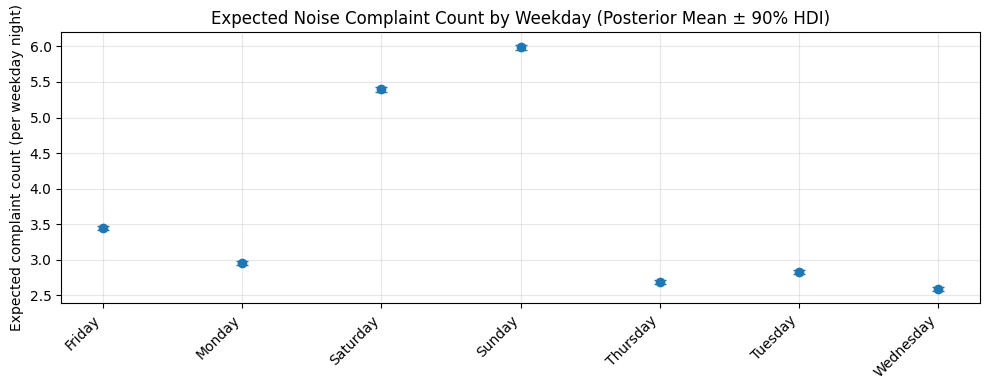

In [23]:
idata = idata_pois_0

mu_da = idata.posterior["mu"]  # dims include "dow"

# Mean per dow
mu_mean = mu_da.mean(dim=("chain", "draw")).to_pandas()  # index = dow

# HDI as a dataframe (works whether az.hdi returns Dataset or DataArray)
hdi_obj = az.hdi(mu_da, hdi_prob=0.90)
hdi_df = hdi_obj.to_dataframe().reset_index()

# Determine variable name column for HDI
mu_name = "mu"
if mu_name not in hdi_df.columns:
    num_cols = [c for c in hdi_df.columns if c not in ["dow", "hdi"]]
    mu_name = num_cols[0]

hdi_wide = (
    hdi_df.pivot(index="dow", columns="hdi", values=mu_name)
    .rename(columns={"lower": "low", "higher": "high"})
)

# Align everything
mu_mean = mu_mean.sort_index()
hdi_wide = hdi_wide.loc[mu_mean.index]

dow_labels = mu_mean.index.astype(str).to_list()
mean_vals = mu_mean.values
low_vals = hdi_wide["low"].values
high_vals = hdi_wide["high"].values

# Error bars
yerr = np.vstack([mean_vals - low_vals, high_vals - mean_vals])

# Identify min/max (by posterior mean)
imin = int(np.nanargmin(mean_vals))
imax = int(np.nanargmax(mean_vals))

# Plot
x = np.arange(len(dow_labels))
plt.figure(figsize=(10, 4))

# Base (gray) for all
plt.errorbar(
    x, mean_vals, yerr=yerr,
    fmt="o", capsize=4,
    color="gray", alpha=0.7
)

# Highlight max (red)
plt.errorbar(
    x[imax], mean_vals[imax],
    yerr=np.array([[mean_vals[imax] - low_vals[imax]],
                   [high_vals[imax] - mean_vals[imax]]]),
    fmt="o", capsize=6,
    color="red", label=f"Max: {dow_labels[imax]}"
)

# Highlight min (blue)
plt.errorbar(
    x[imin], mean_vals[imin],
    yerr=np.array([[mean_vals[imin] - low_vals[imin]],
                   [high_vals[imin] - mean_vals[imin]]]),
    fmt="o", capsize=6,
    color="blue", label=f"Min: {dow_labels[imin]}"
)

plt.xticks(x, dow_labels, rotation=45, ha="right")
plt.ylabel("Expected complaint count (per weekday night)")
plt.title("Expected Noise Complaint Count by Weekday (Posterior Mean ± 90% HDI)\nRed=Max, Blue=Min")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
# On a given weekday night in the summer, what is the probibility of a specific complaint

In [25]:
y = (df_puma_2022__2024["complaint_count"].to_numpy() >= 1).astype("int8")


In [26]:

# categorical key
keys = df_puma_2022__2024["dow_complaint"].astype(str)  # or dow_complaint if you didn't collapse
codes, dow_complaint_idx = np.unique(keys, return_inverse=True)

coords = {"dow_complaint": codes}


In [27]:
with pm.Model(coords=coords) as model_cdow_0:

    p = pm.Beta("p", alpha=1, beta=1, dims="dow_complaint")

    y_obs = pm.Bernoulli("y_obs", p=p[dow_complaint_idx], observed=y)

    idata_1 = pm.sample(draws=1000, tune=1000, chains=4, target_accept=0.9, random_seed=42)
   

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 72 seconds.


In [28]:
az.summary(idata_1, var_names=["p"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p[BANGING/POUNDING__Friday],0.999,0.001,0.998,1.0,0.0,0.0,4166.0,1923.0,1.0
p[BANGING/POUNDING__Monday],0.999,0.001,0.998,1.0,0.0,0.0,3861.0,2077.0,1.0
p[BANGING/POUNDING__Saturday],0.999,0.001,0.998,1.0,0.0,0.0,4350.0,1875.0,1.0
p[BANGING/POUNDING__Sunday],0.999,0.001,0.998,1.0,0.0,0.0,4309.0,2259.0,1.0
p[BANGING/POUNDING__Thursday],0.999,0.001,0.998,1.0,0.0,0.0,3342.0,1539.0,1.0
...,...,...,...,...,...,...,...,...,...
p[OTHER__Saturday],0.990,0.010,0.971,1.0,0.0,0.0,3221.0,1454.0,1.0
p[OTHER__Sunday],0.989,0.011,0.969,1.0,0.0,0.0,3221.0,1573.0,1.0
p[OTHER__Thursday],0.990,0.010,0.971,1.0,0.0,0.0,3746.0,1783.0,1.0
p[OTHER__Tuesday],0.987,0.013,0.964,1.0,0.0,0.0,3803.0,1832.0,1.0


In [29]:
with model_cdow_0:
    ppc = pm.sample_posterior_predictive(
        idata_1,
        var_names=["y_obs"],
        random_seed=42
    )


Sampling: [y_obs]


Output()

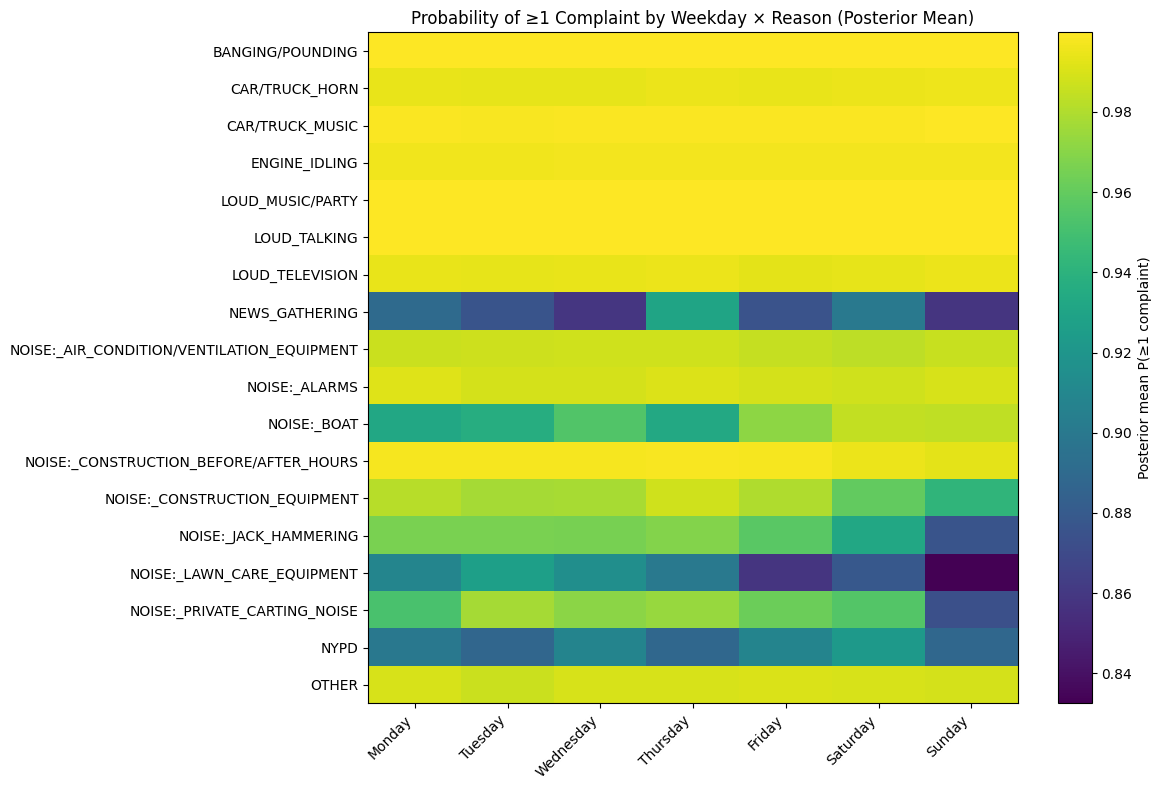

In [30]:

# 1) Extract posterior draws for p (dims: chain, draw, dow_complaint)
p_post = idata_1.posterior["p"]  # xarray DataArray

# Posterior mean per dow_complaint label
p_mean = p_post.mean(dim=("chain", "draw")).to_pandas()  # index = dow_complaint labels

# 2) Turn into a tidy table by splitting the label
df = (
    p_mean.rename("p_mean")
    .reset_index()
    .rename(columns={"dow_complaint": "dow_complaint"})
)

# If your labels are like "NOISE_BARKING_DOG__Thursday"
df[["reason", "dow"]] = df["dow_complaint"].str.rsplit("__", n=1, expand=True)

# Optional: normalize weekday order (if dow is names)
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
if df["dow"].isin(dow_order).any():
    df["dow"] = pd.Categorical(df["dow"], categories=dow_order, ordered=True)

# 3) Keep top-N reasons (prevents a giant unreadable heatmap)
top_n = 20
top_reasons = (
    df_puma_2022__2024["descriptor"]  # or whatever you used in dow_complaint
    .value_counts()
    .head(top_n)
    .index
)

# Match your "reason" naming: if your dow_complaint reason uses underscores
top_reasons_key = {r.replace(" ", "_").upper() for r in top_reasons}
df_small = df[df["reason"].isin(top_reasons_key)].copy()

# 4) Pivot into matrix: rows=reason, cols=dow
mat = df_small.pivot_table(index="reason", columns="dow", values="p_mean", aggfunc="mean")

# 5) Plot heatmap
plt.figure(figsize=(12, 8))
im = plt.imshow(mat.values, aspect="auto")
plt.colorbar(im, label="Posterior mean P(≥1 complaint)")

plt.yticks(np.arange(mat.shape[0]), mat.index)
plt.xticks(np.arange(mat.shape[1]), mat.columns, rotation=45, ha="right")

plt.title("Probability of ≥1 Complaint by Weekday × Reason (Posterior Mean)")
plt.tight_layout()
plt.show()


In [31]:
y = df_puma_2022__2024["complaint_count"].to_numpy().astype("int32")

In [38]:
with pm.Model(coords=coords) as model_pois_1:
 
    log_mu = pm.Normal("log_mu", 0, 2, dims="dow_complaint")
    
    mu = pm.Deterministic("mu", pm.math.exp(log_mu), dims="dow_complaint")
    
    y_obs = pm.Poisson("y_obs", mu=mu[dow_complaint_idx], observed=y)
    
    idata_pois_1 = pm.sample(draws=1000, tune=1000, chains=4, target_accept=0.9, random_seed=42)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [log_mu]


Output()

/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 99 seconds.


In [39]:
az.summary(idata_pois_1)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
log_mu[BANGING/POUNDING__Friday],0.773,0.017,0.741,0.805,0.000,0.000,9470.0,3052.0,1.0
log_mu[BANGING/POUNDING__Monday],0.856,0.017,0.822,0.888,0.000,0.000,9172.0,2491.0,1.0
log_mu[BANGING/POUNDING__Saturday],0.810,0.016,0.780,0.840,0.000,0.000,11482.0,2862.0,1.0
log_mu[BANGING/POUNDING__Sunday],0.854,0.016,0.826,0.883,0.000,0.000,11252.0,2846.0,1.0
log_mu[BANGING/POUNDING__Thursday],0.862,0.017,0.833,0.896,0.000,0.000,12433.0,2464.0,1.0
...,...,...,...,...,...,...,...,...,...
mu[OTHER__Saturday],10.331,0.330,9.673,10.912,0.003,0.008,12039.0,2653.0,1.0
mu[OTHER__Sunday],7.041,0.280,6.498,7.557,0.003,0.005,10688.0,2876.0,1.0
mu[OTHER__Thursday],7.963,0.286,7.412,8.491,0.003,0.005,11664.0,2572.0,1.0
mu[OTHER__Tuesday],6.855,0.304,6.289,7.430,0.003,0.005,10433.0,2679.0,1.0


In [40]:
with model_pois_1:
    ppc_pois_1 = pm.sample_posterior_predictive(
        idata_pois_1,
        var_names=["y_obs"],
        random_seed=42
    )

Sampling: [y_obs]


Output()

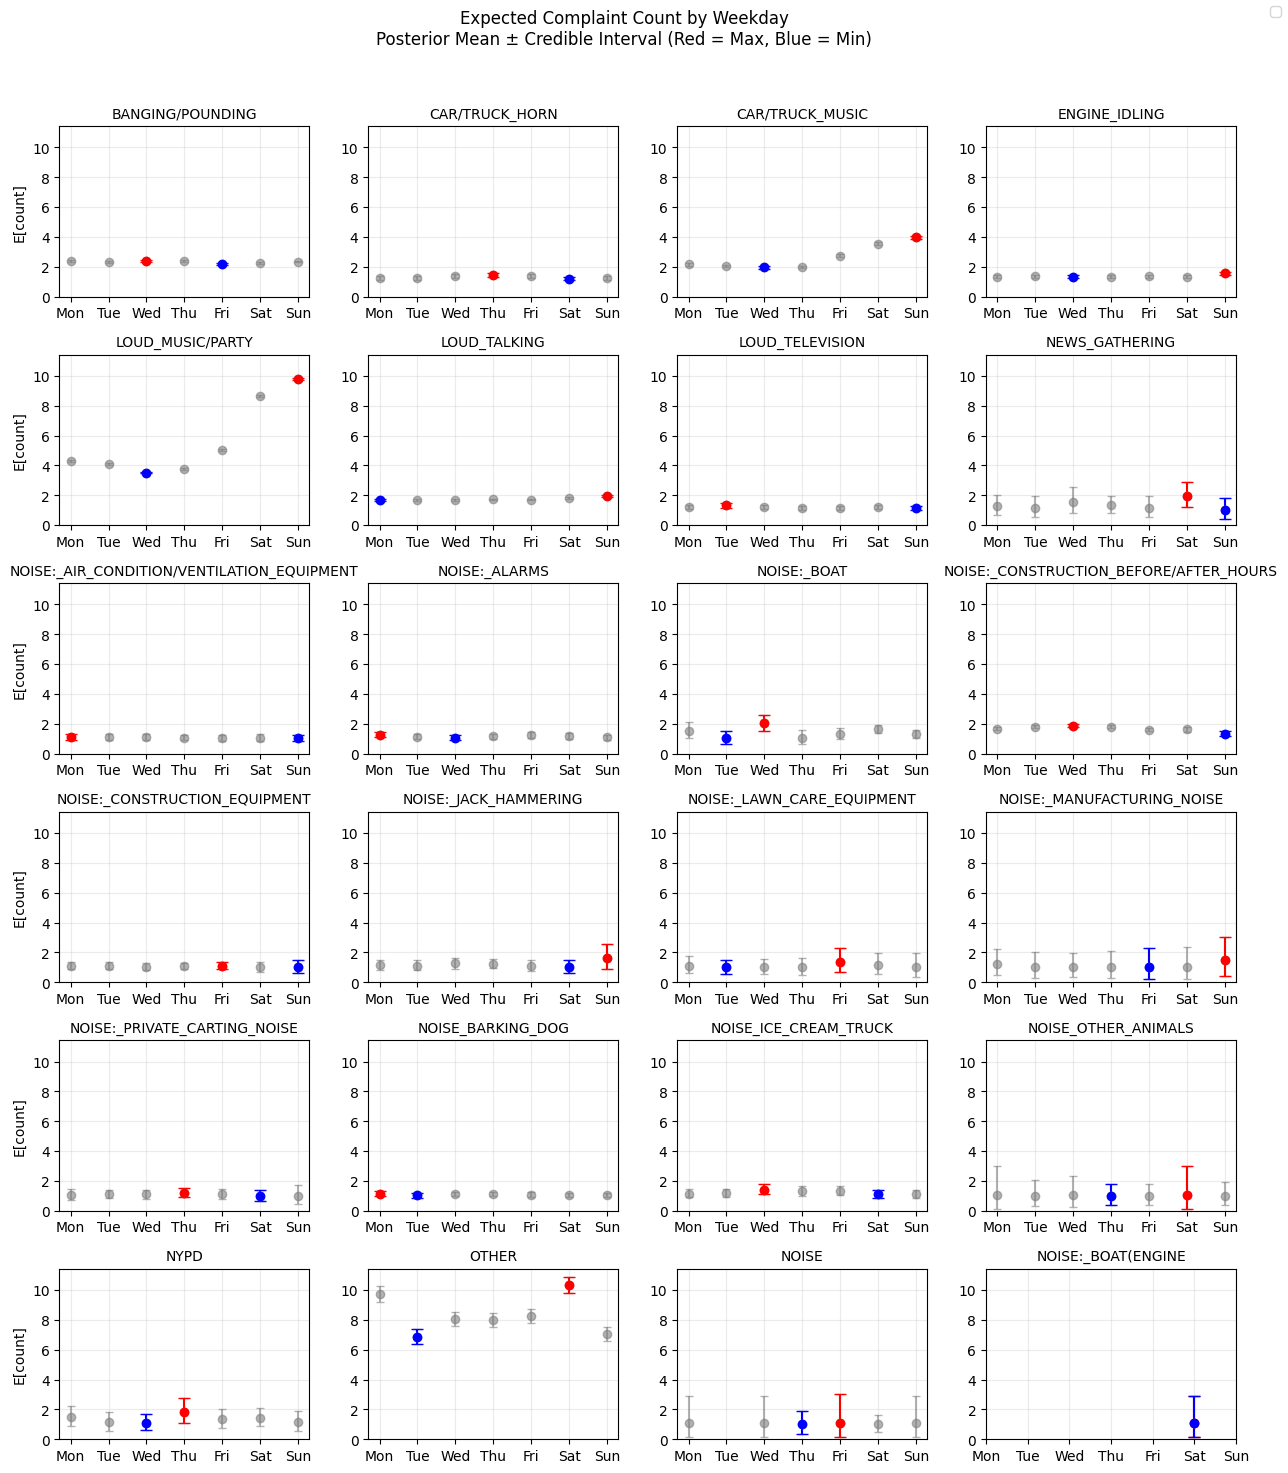

In [43]:
def plot_panel_mu_by_weekday(
    idata,
    *,
    dim_name="dow_complaint",
    mu_name="mu",
    sep="__",
    dow_order=("Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"),
    top_n=24,
    hdi=(0.05, 0.95),
    ncols=4,
    figsize_per_panel=(3.2, 2.4),
):
    mu_da = idata.posterior[mu_name]
    df = mu_da.to_dataframe(name="mu").reset_index()

    parts = df[dim_name].astype(str).str.rsplit(sep, n=1, expand=True)
    df["complaint"] = parts[0]
    df["dow"] = parts[1]

    df["dow"] = pd.Categorical(df["dow"], categories=list(dow_order), ordered=True)

    vc = df["complaint"].value_counts()
    complaints = vc.head(top_n).index.tolist() if top_n else vc.index.tolist()
    df = df[df["complaint"].isin(complaints)]

    q_lo, q_hi = hdi
    agg = (
        df.groupby(["complaint", "dow"])["mu"]
          .agg(mean="mean",
               low=lambda s: s.quantile(q_lo),
               high=lambda s: s.quantile(q_hi))
          .reset_index()
    )

    n = len(complaints)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig = plt.figure(figsize=(figsize_per_panel[0] * ncols,
                              figsize_per_panel[1] * nrows))

    y_max = agg["high"].max() * 1.05

    for i, comp in enumerate(complaints, start=1):
        ax = plt.subplot(nrows, ncols, i)

        sub = (
            agg[agg["complaint"] == comp]
            .set_index("dow")
            .reindex(list(dow_order))
        )

        x = np.arange(len(dow_order))
        y = sub["mean"].to_numpy()
        low = sub["low"].to_numpy()
        high = sub["high"].to_numpy()

        valid = np.isfinite(y) & np.isfinite(low) & np.isfinite(high)
        xv = x[valid]
        yv = y[valid]

        # Base (gray)
        ax.errorbar(
            xv, yv,
            yerr=np.vstack([yv - low[valid], high[valid] - yv]),
            fmt="o",
            color="gray",
            alpha=0.6,
            capsize=3,
        )

        # Identify min / max
        imax = xv[np.nanargmax(yv)]
        imin = xv[np.nanargmin(yv)]

        # Max (red)
        ax.errorbar(
            imax, y[imax],
            yerr=[[y[imax] - low[imax]], [high[imax] - y[imax]]],
            fmt="o",
            color="red",
            capsize=4,
            label="Max" if i == 1 else None,
        )

        # Min (blue)
        ax.errorbar(
            imin, y[imin],
            yerr=[[y[imin] - low[imin]], [high[imin] - y[imin]]],
            fmt="o",
            color="blue",
            capsize=4,
            label="Min" if i == 1 else None,
        )

        ax.set_xticks(x)
        ax.set_xticklabels([d[:3] for d in dow_order])
        ax.set_ylim(0, y_max)
        ax.set_title(comp, fontsize=10)
        ax.grid(True, alpha=0.25)

        if i % ncols == 1:
            ax.set_ylabel("E[count]")

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    fig.suptitle(
        "Expected Complaint Count by Weekday\nPosterior Mean ± Credible Interval "
        "(Red = Max, Blue = Min)",
        y=1.02
    )

    plt.tight_layout()
    plt.show()


# ---- Run it ----
plot_panel_mu_by_weekday(
    idata_pois_1,
    top_n=24,   # increase gradually; set None to try all (may be huge)
    ncols=4
)
